
# FFNN — PyTorch 2.x (simplificado)

Este cuaderno combina el **pipeline compacto** con `torch.compile`, early stopping y utilidades modernas,
**añadiendo** las funciones/clases que tenía tu versión original (datasets, EDA, loops `loop_FFNN/MC`,
`evaluate`, plots, etc.).


In [1]:

# [setup]
import os, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import json
from ucimlrepo import fetch_ucirepo

torch.set_float32_matmul_precision('high')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
os.makedirs('checkpoints', exist_ok=True)
print('Device:', DEVICE)

# --- AÑADIR ESTO PARA REPRODUCIBILIDAD EN GPU ---
if DEVICE == 'cuda':
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Advertencia: Esto puede hacer el código un poco más lento
    torch.use_deterministic_algorithms(True) 
    # Para algunas versiones de CUDA
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"


Device: cuda


/home/vicente/Desktop/Repostitories/DeepLearning/venv/lib/python3.12/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [2]:
# [model core] - REEMPLAZAR CELDA 3

# Función para inicializar los pesos
def init_weights(m, init_method='he'):
    if isinstance(m, nn.Linear):
        if init_method == 'he':
            # Inicialización He (buena para ReLU)
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        elif init_method == 'xavier':
            # Inicialización Xavier (buena para Tanh o Sigmoid)
            nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

def make_mlp(d_in: int, d_hidden=(64, 64), d_out=1, dropout=0.0, 
             act_fn=nn.ReLU, # <--- CAMBIADO (ahora es un parámetro)
             use_bn=False):
    layers = []
    d_prev = d_in
    for i, h in enumerate(d_hidden):
        layers.append(nn.Linear(d_prev, h))
        if use_bn:
            layers.append(nn.BatchNorm1d(h))
        layers.append(act_fn()) # <--- Usa la función de activación
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        d_prev = h
    layers.append(nn.Linear(d_prev, d_out))
    return nn.Sequential(*layers)

@torch.no_grad()
def accuracy_bin(logits, y_true):
    preds = (logits.sigmoid() >= 0.5).float().view(-1)
    return (preds == y_true.view(-1)).float().mean().item()

@torch.no_grad()
def accuracy_multi(logits, y_true):
    preds = logits.argmax(1)
    return (preds == y_true).float().mean().item()

def set_seed(seed=42):
    import random
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [3]:
# [fit loop] - (REEMPLAZAR CELDA 3)
def fit(model, train_ds, val_ds=None, *, epochs=100, batch_size=64, lr=1e-3,
        patience=10, min_delta=1e-4, ckpt_path=None, compile_model=True, 
        weight_decay=0.0, optimizer_name='AdamW'):
    
    model.to(DEVICE)
    if compile_model and hasattr(torch, 'compile') and os.name != 'nt':
        try:
            model = torch.compile(model)
        except Exception as e:
            print('torch.compile no disponible:', e)

    sample_x, sample_y = train_ds[0][0], train_ds[0][1]
    binary = sample_y.ndim == 0 or sample_y.unique().numel() <= 2
    
    if binary:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()

    if optimizer_name.lower() == 'adamw':
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == 'adam':
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == 'sgd':
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        print(f"Advertencia: Optimizador '{optimizer_name}' no reconocido. Usando AdamW.")
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # --- AÑADIR ESTO: LR SCHEDULER ---
    # Reduce el LR por un factor de 0.2 si val_loss no mejora en 5 épocas
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.2, patience=5, min_lr=1e-6)
    # ------------------------------------

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    best = math.inf; best_epoch = None; best_state = None
    history = {'epoch': [], 'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}
    history['epoch_best'] = None 

    for epoch in range(1, epochs+1):
        model.train()
        epoch_loss = 0.0; n = 0; accs = []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            if binary:
                yb_f = yb.float().view(-1,1)
                loss = criterion(logits, yb_f)
                acc = accuracy_bin(logits.detach(), yb.detach().float())
            else:
                loss = criterion(logits, yb.long())
                acc = accuracy_multi(logits.detach(), yb.detach().long())
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            epoch_loss += loss.item()*xb.size(0); n += xb.size(0); accs.append(acc)
        tr_loss = epoch_loss/n; tr_acc = float(np.mean(accs))

        # Validación
        if val_ds is not None:
            model.eval()
            val_loader = DataLoader(val_ds, batch_size=batch_size * 2)
            val_loss_epoch = 0.0; val_acc_epoch = 0.0; n_val = 0
            with torch.no_grad():
                for xb_val, yb_val in val_loader:
                    xb_val, yb_val = xb_val.to(DEVICE), yb_val.to(DEVICE)
                    logits = model(xb_val)
                    if binary:
                        val_loss = criterion(logits, yb_val.float().view(-1,1)).item()
                        val_acc = accuracy_bin(logits, yb_val.float())
                    else:
                        val_loss = criterion(logits, yb_val.long()).item()
                        val_acc = accuracy_multi(logits, yb_val.long())
                    val_loss_epoch += val_loss * xb_val.size(0)
                    val_acc_epoch += val_acc * xb_val.size(0)
                    n_val += xb_val.size(0)
            
            val_loss = val_loss_epoch / n_val
            val_acc = val_acc_epoch / n_val

            # --- AÑADIR ESTO: PASO DEL SCHEDULER ---
            scheduler.step(val_loss) 
            # ----------------------------------------
            
            if val_loss + min_delta < best:
                best = val_loss; best_epoch = epoch; best_state = {k:v.cpu() for k,v in model.state_dict().items()}
                if ckpt_path: torch.save(best_state, ckpt_path)

        history['epoch'].append(epoch)
        history['loss'].append(tr_loss); history['acc'].append(tr_acc)
        if val_ds is not None:
            history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)

        if epoch % 5 == 0:
            msg = f"[{epoch:03d}] loss={tr_loss:.4f} acc={tr_acc*100:5.1f}%"
            if val_ds is not None:
                # Mostrar el LR actual
                current_lr = opt.param_groups[0]['lr']
                msg += f" | vloss={val_loss:.4f} vacc={val_acc*100:5.1f}% (LR: {current_lr:.1e})"
            print(msg)

        if val_ds is not None and (epoch - (best_epoch or 0)) >= patience:
            print(f"Paro temprano @ epoch {epoch} (best={best_epoch})\n")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    
    history['epoch_best'] = best_epoch 

    return model, history, best_epoch

In [4]:
# [compat: models with names FFNN / FFNN_MC] - (Modificada para d_hidden)

class FFNN(nn.Module):
    # Binario: salida 1
    def __init__(self, d0, d_hidden=(64, 64), dropout=0.0, use_bn=False, 
                 init_method='he', act_fn=nn.ReLU): # <--- AÑADIDO act_fn
        super().__init__()
        self.net = make_mlp(d0, d_hidden, 1, dropout=dropout, 
                            act_fn=act_fn, use_bn=use_bn) # <--- Pasado a make_mlp
        self.net.apply(lambda m: init_weights(m, init_method=init_method))
        
    def forward(self, x): 
        return self.net(x)

class FFNN_MC(nn.Module):
    # Multiclase: salida C
    # MODIFICADO: Acepta d_hidden=(capa1, capa2, ...)
    def __init__(self, d0, d_hidden=(64, 64), C=3, dropout=0.0, use_bn=False, init_method='he'):
        super().__init__()
        self.net = make_mlp(d0, d_hidden, C, dropout=dropout, act_fn=nn.ReLU, use_bn=use_bn)
        self.net.apply(lambda m: init_weights(m, init_method=init_method))

    def forward(self, x): 
        return self.net(x)

In [5]:

# [compat: evaluation & plotting]
@torch.no_grad()
def evaluate(model, dataset, binary=True, batch_size=256):
    model.eval(); loader = DataLoader(dataset, batch_size=batch_size)
    total=0; correct=0; losses=[]; crit = nn.BCEWithLogitsLoss() if binary else nn.CrossEntropyLoss()
    all_y=[]; all_p=[]
    for xb, yb in loader:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        logits = model(xb)
        if binary:
            loss = crit(logits, yb.float().view(-1,1))
            preds = (logits.sigmoid()>=0.5).float().view(-1)
            all_p.append(preds.cpu().numpy()); all_y.append(yb.view(-1).cpu().numpy())
        else:
            loss = crit(logits, yb.long())
            preds = logits.argmax(1)
            all_p.append(preds.cpu().numpy()); all_y.append(yb.view(-1).cpu().numpy())
        total += yb.size(0); correct += (preds == yb.view(-1)).float().sum().item(); losses.append(loss.item())
    acc = correct/total
    y_true = np.concatenate(all_y); y_pred = np.concatenate(all_p)
    cm = confusion_matrix(y_true, y_pred)

    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {'acc': acc, 'loss': float(np.mean(losses)), 'cm': cm, 'report_dict': rep}

@torch.no_grad()
def evaluate_per_class(model, dataset, binary=False, batch_size=256):
    # simple wrapper que devuelve matriz de confusión y métricas por clase del classification_report
    e = evaluate(model, dataset, binary=binary, batch_size=batch_size)
    return e

def plot_history_loss(h):
    x = h['epoch'];
    plt.figure(); plt.plot(x, h['loss'], label='train_loss')
    if h.get('val_loss'): plt.plot(x, h['val_loss'], label='val_loss')
    plt.xlabel('Época'); plt.ylabel('Loss'); plt.title('Histórico Loss'); plt.legend(); plt.show()

def plot_history_acc(h):
    x = h['epoch'];
    plt.figure(); plt.plot(x, np.array(h['acc'])*100, label='train_acc')
    if h.get('val_acc'): plt.plot(x, np.array(h['val_acc'])*100, label='val_acc')
    plt.xlabel('Época'); plt.ylabel('Acc (%)'); plt.title('Histórico Acc'); plt.legend(); plt.show()

def plot_with_best_epoch(h, best_epoch):
    plot_history_loss(h); plot_history_acc(h)
    if best_epoch:
        print(f"Mejor época (val_loss): {best_epoch}")


In [6]:

# [plots with best epoch]
def plot_history(h, best_epoch=None, title='Histórico'):
    x = h['epoch']
    # Loss
    plt.figure()
    plt.plot(x, h['loss'], label='train_loss')
    if h.get('val_loss') and len(h['val_loss']) == len(x):
        plt.plot(x, h['val_loss'], label='val_loss')
    if best_epoch:
        plt.axvline(best_epoch, linestyle='--')
        plt.text(best_epoch, plt.ylim()[1]*0.9, f"best={best_epoch}", rotation=90, va='top')
    plt.xlabel('Época'); plt.ylabel('Loss'); plt.title(title + ' - Loss'); plt.legend(); plt.show()
    # Acc
    plt.figure()
    plt.plot(x, [a*100 for a in h['acc']], label='train_acc')
    if h.get('val_acc') and len(h['val_acc']) == len(x):
        plt.plot(x, [a*100 for a in h['val_acc']], label='val_acc')
    if best_epoch:
        plt.axvline(best_epoch, linestyle='--')
        plt.text(best_epoch, plt.ylim()[1]*0.9, f"best={best_epoch}", rotation=90, va='top')
    plt.xlabel('Época'); plt.ylabel('Acc (%)'); plt.title(title + ' - Acc'); plt.legend(); plt.show()

def plot_with_best_epoch(h, best_epoch):
    plot_history(h, best_epoch=best_epoch, title='Entrenamiento')


In [ ]:
np.random.seed(42)
print("Cargando dataset Online News Popularity...")
online_news_popularity = fetch_ucirepo(id=332) 
X_df = online_news_popularity.data.features 
y_df = online_news_popularity.data.targets 

# Binarizar 'y' para clasificación
UMBRAL_POPULARIDAD = 1400 
y_binned = (y_df > UMBRAL_POPULARIDAD).astype(float)

X_data = X_df.to_numpy()
y_data = y_binned.to_numpy()
d0 = X_data.shape[1] # Dimensión de entrada

print(f"Dataset cargado. {X_data.shape[0]} muestras, {d0} características.")
print(f"Problema: Clasificación Binaria (Popular > {UMBRAL_POPULARIDAD} shares)")

# Estandarizar X (¡Muy importante!)
scaler = StandardScaler()
# scaler = MinMaxSca
X_data_scaled = scaler.fit_transform(X_data)


# Dividir en Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_data_scaled, y_data, 
    test_size=0.2, stratify=y_data, random_state=42
)
# Dividir Train en Train/Validación (60/20 del total)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.25, # 0.25 * 0.8 = 0.2 del total
    stratify=y_train, random_state=42
)

# Convertir a TensorDatasets
ds_train = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.float32))
ds_val = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
ds_test = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

print(f"Datos divididos: {len(ds_train)} train, {len(ds_val)} val, {len(ds_test)} test")

Cargando dataset Online News Popularity...
Dataset cargado. 39644 muestras, 58 características.
Problema: Clasificación Binaria (Popular > 1400 shares)
Datos divididos: 23786 train, 7929 val, 7929 test



--- Iniciando Grid Search en cuda ---

--- Entrenando: 1. Base AdamW (64, 64) ---
[005] loss=0.6114 acc= 66.2% | vloss=0.6318 vacc= 64.5% (LR: 1.0e-03)
[010] loss=0.5910 acc= 68.2% | vloss=0.6306 vacc= 64.9% (LR: 1.0e-03)
[015] loss=0.5716 acc= 69.9% | vloss=0.6321 vacc= 65.1% (LR: 2.0e-04)
Paro temprano @ epoch 17 (best=7)

Evaluando 1. Base AdamW (64, 64) en el conjunto de Test...

--- Entrenando: 2. Base SGD (64, 64) + L2 leve ---
[005] loss=0.6630 acc= 60.4% | vloss=0.6661 vacc= 60.4% (LR: 1.0e-03)
[010] loss=0.6490 acc= 62.1% | vloss=0.6560 vacc= 61.7% (LR: 1.0e-03)
[015] loss=0.6424 acc= 62.9% | vloss=0.6508 vacc= 62.2% (LR: 1.0e-03)
[020] loss=0.6381 acc= 63.5% | vloss=0.6475 vacc= 63.0% (LR: 1.0e-03)
[025] loss=0.6348 acc= 63.9% | vloss=0.6450 vacc= 63.1% (LR: 1.0e-03)
[030] loss=0.6321 acc= 64.0% | vloss=0.6430 vacc= 63.2% (LR: 1.0e-03)
[035] loss=0.6298 acc= 64.4% | vloss=0.6413 vacc= 63.2% (LR: 1.0e-03)
[040] loss=0.6277 acc= 64.7% | vloss=0.6399 vacc= 63.2% (LR: 1.0e-03)
[

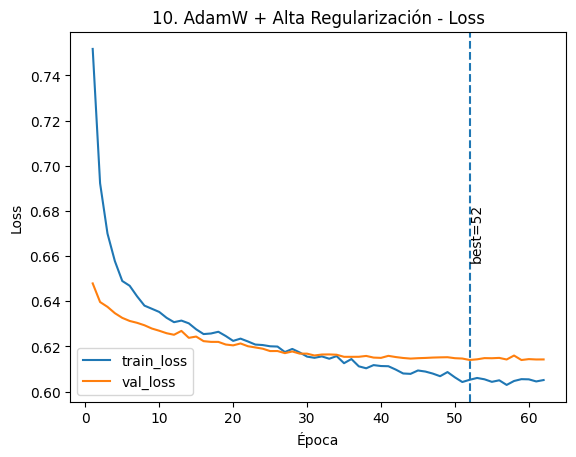

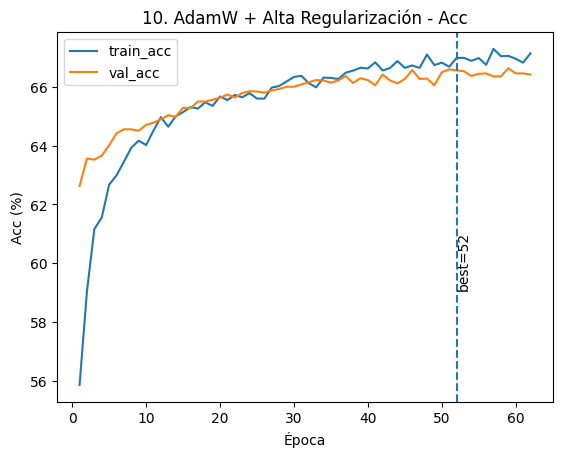

In [8]:
# [Grid Search / Bucle de Experimentos] - (MODIFICADO Y AMPLIADO)

# Definición de tus experimentos
# Aquí probamos sistemáticamente cada técnica
configurations = [
    # --- BASES ---
    {
        "name": "1. Base AdamW (64, 64)",
        "d_hidden": (64, 64),
        "dropout": 0.0, "use_bn": False, "init_method": "he",
        "weight_decay": 0.0, "optimizer_name": "AdamW"
    },
    {
        "name": "2. Base SGD (64, 64) + L2 leve",
        "d_hidden": (64, 64),
        "dropout": 0.0, "use_bn": False, "init_method": "he",
        "weight_decay": 1e-4, "optimizer_name": "SGD" # Usando SGD
    },
    
    # --- PRUEBAS DE REGULARIZACIÓN (sobre AdamW) ---
    {
        "name": "3. AdamW + Dropout (0.5)",
        "d_hidden": (64, 64),
        "dropout": 0.5, "use_bn": False, "init_method": "he",
        "weight_decay": 0.0, "optimizer_name": "AdamW"
    },
    {
        "name": "4. AdamW + L2 (1e-3)",
        "d_hidden": (64, 64),
        "dropout": 0.0, "use_bn": False, "init_method": "he",
        "weight_decay": 1e-3, "optimizer_name": "AdamW" # L2 Fuerte
    },
    {
        "name": "5. AdamW + Batch Norm",
        "d_hidden": (64, 64),
        "dropout": 0.0, "use_bn": True, "init_method": "he",
        "weight_decay": 0.0, "optimizer_name": "AdamW"
    },

    # --- PRUEBAS DE INICIALIZACIÓN ---
    {
        "name": "6. AdamW + Xavier Init",
        "d_hidden": (64, 64),
        "dropout": 0.0, "use_bn": False, "init_method": "xavier", # Xavier
        "weight_decay": 0.0, "optimizer_name": "AdamW"
    },

    # --- PRUEBAS DE ARQUITECTURA (combinando técnicas) ---
    {
        "name": "7. Red Profunda (128, 64, 32) + Regs",
        "d_hidden": (128, 64, 32), # 3 capas
        "dropout": 0.3, "use_bn": True, "init_method": "he",
        "weight_decay": 1e-4, "optimizer_name": "AdamW"
    },
    {
        "name": "8. Red Ancha (256, 128) + Regs",
        "d_hidden": (256, 128), # 2 capas anchas
        "dropout": 0.3, "use_bn": True, "init_method": "he",
        "weight_decay": 1e-4, "optimizer_name": "AdamW"
    },
    {
        "name": "9. Red Profunda (128, 64, 32) + SGD",
        "d_hidden": (128, 64, 32),
        "dropout": 0.3, "use_bn": True, "init_method": "he",
        "weight_decay": 1e-4, "optimizer_name": "SGD" # SGD en red compleja
    },
    {
        "name": "10. AdamW + Alta Regularización",
        "d_hidden": (128, 64),
        "dropout": 0.5, "use_bn": True, "init_method": "he",
        "weight_decay": 1e-3, "optimizer_name": "AdamW" # L2 Fuerte + Dropout Fuerte
    },
    {
        "name": "11. Mejor Modelo + GELU",
        "d_hidden": (128, 64), "dropout": 0.5, "use_bn": True,
        "weight_decay": 1e-3, "optimizer_name": "AdamW", "lr": 1e-3,
        "act_fn": nn.GELU 
    },
    {
        "name": "12. Mejor Modelo + SiLU",
        "d_hidden": (128, 64), "dropout": 0.5, "use_bn": True,
        "weight_decay": 1e-3, "optimizer_name": "AdamW", "lr": 1e-3,
        "act_fn": nn.SiLU 
    }
]

results_summary = []
all_histories = {}
all_models = {}

# Nombres de los archivos de salida
RESULTS_CSV_PATH = "news_popularity_results.csv"
HISTORIES_JSON_PATH = "news_popularity_histories.json"
CHECKPOINTS_DIR = "checkpoints"

print(f"\n--- Iniciando Grid Search en {DEVICE} ---")
if 'd0' not in locals():
    print("ERROR: Por favor, ejecuta la celda [Carga de datos] (Celda 7) primero.")
else:
    for config in configurations:
        print(f"\n--- Entrenando: {config['name']} ---")
        
        set_seed(42)

        # 1. Crear Modelo
        model = FFNN(
            d0, 
            d_hidden=config['d_hidden'],
            dropout=config['dropout'], 
            use_bn=config['use_bn'],
            init_method=config.get('init_method', 'he'),
            act_fn=config.get('act_fn', nn.ReLU)
        )
        
        # 2. Definir ruta para guardar el modelo
        model_filename = config['name'].replace(' ', '_').replace('/', '_') + "_best.pth"
        ckpt_path = os.path.join(CHECKPOINTS_DIR, model_filename)
        
        # 3. Entrenar Modelo
        model, history, best_epoch = fit(
            model, 
            ds_train, 
            val_ds=ds_val,
            epochs=100, 
            lr=1e-3,
            batch_size=256, 
            patience=10, 
            weight_decay=config['weight_decay'],
            optimizer_name=config['optimizer_name'],
            compile_model=False,
            ckpt_path=ckpt_path  # <--- AÑADIDO: Guardar el mejor modelo
        )
        
        # 4. Evaluar en Test
        print(f"Evaluando {config['name']} en el conjunto de Test...")
        test_eval = evaluate(model, ds_test, binary=True)
        
        # 5. Guardar resultados (MODIFICADO)
        
        # Copiamos la configuración base
        summary_data = config.copy()
        
        # Convertimos d_hidden (tuple) a string para que sea amigable con CSV
        summary_data['d_hidden'] = str(summary_data['d_hidden'])
        
        # Añadimos métricas de entrenamiento
        summary_data['best_epoch'] = best_epoch
        summary_data['total_epochs'] = len(history['epoch'])
        if best_epoch:
             # Obtenemos las métricas del mejor epoch de validación
            best_idx = best_epoch - 1
            summary_data['best_val_loss'] = history['val_loss'][best_idx]
            summary_data['best_val_acc'] = history['val_acc'][best_idx]
        
        # Añadimos métricas de Test
        summary_data['test_acc'] = test_eval['acc']
        summary_data['test_loss'] = test_eval['loss']
        
        # Añadimos Precision, Recall, F1 de la clase 1.0 (Popular)
        report_class_1 = test_eval['report_dict'].get('1.0', {})
        summary_data['test_precision(1)'] = report_class_1.get('precision')
        summary_data['test_recall(1)'] = report_class_1.get('recall')
        summary_data['test_f1-score(1)'] = report_class_1.get('f1-score')

        results_summary.append(summary_data)
        all_histories[config['name']] = history
        all_models[config['name']] = model # (Opcional, consume memoria)

    print("\n--- Resultados del Grid Search (News Popularity) ---")
    results_df = pd.DataFrame(results_summary).sort_values(by="test_acc", ascending=False)
    
    # Mostrar resultados en pantalla
    print(results_df.to_markdown(index=False))
    
    # --- GUARDAR ARCHIVOS ---
    
    # 1. Guardar Métricas Clave en CSV
    results_df.to_csv(RESULTS_CSV_PATH, index=False)
    print(f"\nResultados guardados en: {RESULTS_CSV_PATH}")

    # 2. Guardar Historiales en JSON
    # (Necesitamos convertir tensores/numpy a listas si los hubiera, aunque aquí 'history' ya es clean)
    with open(HISTORIES_JSON_PATH, "w") as f:
        json.dump(all_histories, f, indent=4)
    print(f"Historiales de entrenamiento guardados en: {HISTORIES_JSON_PATH}")

    # 3. Modelos (ya guardados)
    print(f"Los mejores checkpoints de los modelos se han guardado en la carpeta: '{CHECKPOINTS_DIR}/'")

    # Graficar el historial del mejor modelo
    if not results_df.empty:
        best_model_name = results_df.iloc[0]['name']
        best_model_epoch = results_df.iloc[0]['best_epoch']
        print(f"\n--- Historial del Mejor Modelo: {best_model_name} ---")
        plot_history(all_histories[best_model_name], best_epoch=best_model_epoch, title=best_model_name)
    else:
        print("No se completaron los entrenamientos.")

In [9]:
# --- Celda 9: Bootstrap (Bagging) (NUEVA) ---
# [Bootstrap (Bagging)]

# [Bootstrap (Bagging)] - (Celda 9 MODIFICADA)

def run_bootstrap_experiment(train_dataset, val_dataset, test_dataset, n_models=10):
    
    print(f"\n--- Iniciando Bootstrap (Bagging) con {n_models} modelos ---")
    
    d0 = train_dataset[0][0].shape[0] 
    ensemble_models = []
    
    for i in range(n_models):
        print(f"Entrenando modelo de bootstrap {i+1}/{n_models}...")
        
        # 1. Crear muestra de bootstrap... (esto queda igual)
        n_train = len(train_dataset)
        indices = torch.randint(0, n_train, (n_train,), device='cpu') 
        bootstrap_train_ds = Subset(train_dataset, indices)
        
        set_seed(42 + i)

        # --- 2. MODIFICACIÓN AQUÍ ---
        # Usamos la configuración ganadora de la Celda 8
        model = FFNN(
            d0, 
            d_hidden=(128, 64),     # <- Mejor arquitectura
            dropout=0.5,            # <- Mejor dropout
            use_bn=True,            # <- Mejor BN
            init_method='he',
            act_fn=nn.SiLU
        )
        
        model, hist, best = fit(
            model, 
            bootstrap_train_ds, 
            val_ds=val_dataset,
            epochs=100, 
            lr=1e-3,                
            batch_size=256,
            patience=10,
            weight_decay=1e-3,      # <- Mejor L2
            optimizer_name='AdamW', # <- Mejor Optimizador
            compile_model=False
        )
        # --- FIN DE LA MODIFICACIÓN ---
        
        ensemble_models.append(model)
        
    print("--- Entrenamiento de Bootstrap finalizado ---")
    return ensemble_models

# ... (La función evaluate_ensemble() queda igual) ...


# --- Función para evaluar un ensemble (sirve para Bootstrap y Ensemble mixto) ---
@torch.no_grad()
def evaluate_ensemble(models, test_dataset, binary=True):
    all_preds = []
    
    # Poner todos los modelos en modo evaluación
    for model in models:
        model.eval()
        model.to(DEVICE)

    # Obtenemos las predicciones (logits) de cada modelo
    # Usamos DataLoader para el test set por si es muy grande
    test_loader = DataLoader(test_dataset, batch_size=512)
    all_logits = [[] for _ in models]
    all_yb = []

    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        all_yb.append(yb.cpu())
        
        for i, model in enumerate(models):
            logits = model(xb)
            all_logits[i].append(logits.cpu())

    # Concatenar resultados de los batches
    all_yb_tensor = torch.cat(all_yb, dim=0)
    all_logits_tensor = [torch.cat(logs, dim=0) for logs in all_logits]

    # Calcular predicciones finales de cada modelo
    all_preds = []
    for logits in all_logits_tensor:
        if binary:
            preds = (logits.sigmoid() >= 0.5).float() # Predicciones 0 o 1
        else:
            preds = logits.argmax(dim=1).float() # Predicciones 0, 1, 2...
        all_preds.append(preds.view(-1, 1))
    
    # Concatenar todas las predicciones (shape: [N_muestras, N_modelos])
    all_preds_tensor = torch.cat(all_preds, dim=1)
    
    # Votación por mayoría
    if binary:
        # Para binario, la media > 0.5 es voto mayoritario para 1
        ensemble_preds = (all_preds_tensor.mean(dim=1) >= 0.5).float()
    else:
        # Para multiclase, usamos 'torch.mode'
        ensemble_preds = torch.mode(all_preds_tensor, dim=1).values
        
    # Calcular precisión final del ensemble
    y_true = all_yb_tensor.float().view(-1)
    acc = (ensemble_preds == y_true).float().mean().item()
    
    print("\n--- Evaluación del Ensemble ---")
    print(f"Precisión del Ensemble (Voto Mayoritario): {acc*100:.2f}%")
    
    print("Reporte de Clasificación del Ensemble:")
    print(classification_report(y_true.numpy(), ensemble_preds.numpy()))
    
    print("Matriz de Confusión del Ensemble:")
    print(confusion_matrix(y_true.numpy(), ensemble_preds.numpy()))
    
    return acc

# --- Ejecutar el experimento de Bootstrap ---
# (Usamos los ds_train, ds_val, ds_test de la celda 7)
bootstrap_models = run_bootstrap_experiment(ds_train, ds_val, ds_test, n_models=7) # 7 o 10 modelos
evaluate_ensemble(bootstrap_models, ds_test, binary=True)


--- Iniciando Bootstrap (Bagging) con 7 modelos ---
Entrenando modelo de bootstrap 1/7...
[005] loss=0.6423 acc= 63.3% | vloss=0.6304 vacc= 64.6% (LR: 1.0e-03)
[010] loss=0.6276 acc= 64.9% | vloss=0.6242 vacc= 64.9% (LR: 1.0e-03)
[015] loss=0.6219 acc= 65.5% | vloss=0.6205 vacc= 65.2% (LR: 1.0e-03)
[020] loss=0.6184 acc= 65.7% | vloss=0.6191 vacc= 65.3% (LR: 1.0e-03)
[025] loss=0.6131 acc= 66.0% | vloss=0.6191 vacc= 65.3% (LR: 1.0e-03)
[030] loss=0.6095 acc= 66.3% | vloss=0.6179 vacc= 65.6% (LR: 1.0e-03)
[035] loss=0.6048 acc= 66.5% | vloss=0.6169 vacc= 65.9% (LR: 2.0e-04)
Paro temprano @ epoch 39 (best=29)

Entrenando modelo de bootstrap 2/7...
[005] loss=0.6466 acc= 62.7% | vloss=0.6291 vacc= 64.4% (LR: 1.0e-03)
[010] loss=0.6320 acc= 64.4% | vloss=0.6246 vacc= 65.0% (LR: 1.0e-03)
[015] loss=0.6240 acc= 65.0% | vloss=0.6252 vacc= 65.0% (LR: 1.0e-03)
[020] loss=0.6198 acc= 65.6% | vloss=0.6204 vacc= 65.4% (LR: 1.0e-03)
[025] loss=0.6170 acc= 65.6% | vloss=0.6190 vacc= 65.5% (LR: 1.0e

0.6584689021110535

In [10]:
# [Ensemble Mixto] - (MODIFICADA para usar los MEJORES modelos)

# --- Define cuántos de los mejores modelos quieres combinar ---
N_TOP_MODELS_FOR_ENSEMBLE = 5
# (Puedes cambiar esto a 5 si quieres probar un ensemble más grande)
# -------------------------------------------------------------

print(f"\n--- Iniciando Ensemble Mixto (Top {N_TOP_MODELS_FOR_ENSEMBLE} Modelos del Grid Search) ---")

try:
    # 1. Asegúrate de que results_df exista (de la Celda 8)
    if 'results_df' not in locals():
        print("Error: 'results_df' no encontrado.")
        print("Por favor, ejecuta la celda [Grid Search / Bucle de Experimentos] (Celda 8) primero.")
    else:
        # 2. Obtener los nombres de los N mejores modelos
        # results_df ya está ordenado por 'test_acc' (descendente)
        top_model_names = results_df.head(N_TOP_MODELS_FOR_ENSEMBLE)['name'].tolist()
        
        print("Modelos seleccionados para el ensemble:")
        for name in top_model_names:
            print(f"- {name}")
            
        # 3. Obtener los modelos entrenados desde el diccionario 'all_models'
        mixed_ensemble_models = [all_models[name] for name in top_model_names]

        # 4. Evaluar el ensemble mixto
        # (Usando la función evaluate_ensemble() definida en la Celda 9)
        evaluate_ensemble(mixed_ensemble_models, ds_test, binary=True)

except NameError:
    print("Error: Debes ejecutar la celda [Grid Search / Bucle de Experimentos] (Celda 8) primero.")
except KeyError as e:
    print(f"Error: No se encontró el modelo '{e.args[0]}'.")
    print("Asegúrate de que los nombres en 'configurations' (Celda 8) sean únicos.")


--- Iniciando Ensemble Mixto (Top 5 Modelos del Grid Search) ---
Modelos seleccionados para el ensemble:
- 10. AdamW + Alta Regularización
- 11. Mejor Modelo + GELU
- 7. Red Profunda (128, 64, 32) + Regs
- 12. Mejor Modelo + SiLU
- 8. Red Ancha (256, 128) + Regs

--- Evaluación del Ensemble ---
Precisión del Ensemble (Voto Mayoritario): 66.24%
Reporte de Clasificación del Ensemble:
              precision    recall  f1-score   support

         0.0       0.67      0.65      0.66      4017
         1.0       0.65      0.67      0.66      3912

    accuracy                           0.66      7929
   macro avg       0.66      0.66      0.66      7929
weighted avg       0.66      0.66      0.66      7929

Matriz de Confusión del Ensemble:
[[2630 1387]
 [1290 2622]]
